<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/7/78/Eindhoven_University_of_Technology_logo_new.png?20231008195526" alt="TU/e Logo" width="200px"/>
</p>

# Assignment 1: Energy Prediction

**Course:** 1BM110 - Data-driven Artificial Intelligence  
**Date:** *Q3 - 2026*  

---

## Group 2

- **Amirhossein Setayeshgar**  
  ✉️ [a.setayeshgar@student.tue.nl](mailto:a.setayeshgar@student.tue.nl)

- **Tijn van der Zwan**  
  ✉️ [t.v.d.zwan@student.tue.nl](mailto:t.v.d.zwan@student.tue.nl)

- **Sadra Moosavi Lar**  
  ✉️ [s.s.moosavi.lar@student.tue.nl](mailto:s.s.moosavi.lar@student.tue.nl)

- **Tariq Oduber**  
  ✉️ [t.j.oduber@student.tue.nl](mailto:t.j.oduber@student.tue.nl)
---

**Repository:** [GitHub – Group 2 Repo](https://github.com/sadra-hub/1BM110-dataDrivenAI)

---

## Problem Description
Imagine it is February 2024 and you work as a data scientist consultant. The Government of the Netherlands wants to regulate the amount of energy generated by fossil sources, limiting it when greener alternatives are available. In particular, they are interested in predicting the energy generated by non-renewable sources (Fossil Gas, Fossil Hard coal and Nuclear) for each day from February 2024 until the end of January 2025.
You have access to data on energy generation from the whole year 2023 and the month of January 2024. The amount of energy generated (in MW) across the country was registered every 15 minutes for 21 different sources.

Your task is to design and implement a time series forecasting model using a recurrent neural network architecture (e.g., LSTM) to predict the energy generated daily by the aggregation of all non-renewable sources (Fossil Gas, Fossil Hard coal and Nuclear) , based on the amount of energy generated by the same sources during the previous days.
The data available for model training and selection is in the file `energy_generation_train.csv`. This dataset contains the amount of energy generated from the beginning of January 2023 to the end of  January 2024. A separate dataset for testing is available in the file `energy_generation_test.csv`. This dataset contains the amount of energy generated from the beginning of February 2024 to the end of January 2025 that should be predicted.

In [7]:
# import packages

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras_tuner as kt
import keras
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
## Version check
print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

if not sys.version.startswith("3.11.11"):
    print("WARNING: Python version should be 3.11.11")

if tf.__version__ != "2.18.0":
    print("WARNING: TensorFlow version should be 2.18.0")

if keras.__version__ != "3.8.0":
    print("WARNING: Keras version should be 3.8.0")

Python version: 3.11.11 (main, Dec 11 2024, 10:25:04) [Clang 14.0.6 ]
TensorFlow version: 2.18.0
Keras version: 3.8.0


✅ Version Check Complete

## Part 1

<span style="color:red">

- Load the dataset provided. **(3 pts)**
- Ensure all columns have the correct data type, e.g., `float` or `int` for numeric quantities, `object` for categorical variables, `datetime` for dates, etc.
- Remove columns where all values are missing or equal to zero.
- Describe the basic statistics (mean, minimum, maximum, standard deviation, etc.) of the numerical variables.

</span>

In [9]:
# Load datasets
train = pd.read_csv('energy_generation_train.csv')
test = pd.read_csv('energy_generation_test.csv')

def process(df, name):
    print(f"\n{'='*50}\nProcessing {name}\n{'='*50}")
    
    # Convert DateTime column (if present) to datetime
    if 'DateTime' in df.columns:
        df['DateTime'] = pd.to_datetime(df['DateTime'])
    
    # Identify numeric columns (everything except DateTime)
    numeric_cols = [c for c in df.columns if c != 'DateTime']
    
    # Remove columns where all values are either missing OR zero
    # (i.e., after filling NaN with 0, all values become 0)
    cols_to_drop = []
    for col in numeric_cols:
        if df[col].fillna(0).eq(0).all():
            cols_to_drop.append(col)
    
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
        print(f"Dropped columns (all missing/zero): {cols_to_drop}")
    
    # Remaining numeric columns
    remaining_numeric = [c for c in df.columns if c != 'DateTime']
    
    # Basic statistics for numerical variables
    if remaining_numeric:
        stats = df[remaining_numeric].describe().T[['mean','min','max','std']]
        stats['missing'] = df[remaining_numeric].isnull().sum()
        print("\nNumerical statistics:")
        print(stats.round(2))
    else:
        print("No numerical columns remaining.")
    
    print(f"\nFinal columns: {list(df.columns)}")
    return df

# Process both sets
train_clean = process(train, 'TRAIN Dataset')
test_clean = process(test, 'TEST Dataset')



Processing TRAIN Dataset
Dropped columns (all missing/zero): ['Biomass', 'Fossil Brown coal/Lignite', 'Fossil Coal-derived gas', 'Fossil Oil', 'Fossil Oil shale', 'Fossil Peat', 'Geothermal', 'Hydro Pumped Storage', 'Hydro Pumped Storage.1', 'Hydro Run-of-river and poundage', 'Hydro Water Reservoir', 'Marine', 'Other renewable']

Numerical statistics:
                     mean  min      max      std  missing
Fossil Gas        3512.53  0.0   9666.0  2256.92       27
Fossil Hard coal  1362.93  0.0   3912.0   999.45       27
Nuclear            433.14  0.0    490.0   135.73       26
Other              351.87  0.0  11638.0   292.84       26
Solar               33.59  0.0    252.0    56.98       26
Waste               62.45  0.0     89.0    17.87       27
Wind Offshore     1296.40  0.0   3339.0   966.51       26
Wind Onshore       431.28  0.0   1226.0   347.33       26

Final columns: ['DateTime', 'Fossil Gas', 'Fossil Hard coal', 'Nuclear', 'Other', 'Solar', 'Waste', 'Wind Offshore', 'Wind

## Part 2

<span style="color:red">

- Perform all data pre-processing steps needed for the model (i.e., integration, cleaning, reduction, and transformation). **(7 pts)**  
- For each pre-processing step that you apply, dedicate at least one markdown cell next to the code to explain:
   - the step you are applying
   - why you need to do it
   - what is the result  

   **Note:** In some scenarios, it is acceptable to repeat steps; however, make sure your code is logical and efficient.

</span>



### Step 2.1: Aggregate from 15-min to Daily

The first preprocessing step was to aggregate the original 15-minute energy generation measurements into daily values using a daily sum. This step was necessary because the assignment requires predicting daily non-renewable energy generation, so the data had to be brought to the same time scale as the forecasting target. As a result, the original high-frequency dataset was transformed into a daily time series with **396 observations** for the training set and **366 observations** for the test set, making the data more suitable for the prediction task.

In [10]:
def to_daily(df, name):
    df = df.copy()
    df['DateTime'] = pd.to_datetime(df['DateTime'])
    df = df.set_index('DateTime').sort_index()

    # daily sum because values are measured every 15 minutes (power in MW)
    daily = df.resample('D').sum()

    print(f"\n{name} daily shape:", daily.shape)
    print(f"{name} daily date range:", daily.index.min(), "->", daily.index.max())
    return daily

train_daily = to_daily(train_clean, "TRAIN")
test_daily  = to_daily(test_clean, "TEST")

train_daily.head()


TRAIN daily shape: (396, 8)
TRAIN daily date range: 2023-01-01 00:00:00 -> 2024-01-31 00:00:00

TEST daily shape: (366, 8)
TEST daily date range: 2024-02-01 00:00:00 -> 2025-01-31 00:00:00


,Fossil Gas,Fossil Hard coal,Nuclear,Other,Solar,Waste,Wind Offshore,Wind Onshore
DateTime,,,,,,,,
2023-01-01,108651.0,120822.0,46548.0,23428.0,756.0,6637.0,128671.0,62959.0
2023-01-02,173299.0,187232.0,46599.0,34205.0,421.0,6662.0,74843.0,40308.0
2023-01-03,182228.0,265139.0,46598.0,38283.0,325.0,6618.0,136001.0,48482.0
2023-01-04,94086.0,192753.0,46574.0,31916.0,248.0,6129.0,211389.0,95278.0
2023-01-05,206362.0,231197.0,46571.0,38189.0,386.0,6402.0,158408.0,66020.0


### Step 2.2: Keep relevant sources and create target

The next step was to keep only the three relevant non-renewable energy sources—Fossil Gas, Fossil Hard coal, and Nuclear—and then create a new variable called target by summing these three sources for each day. This was needed because the assignment specifically asks for predicting the total daily non-renewable energy generation, so keeping unrelated variables would only add unnecessary complexity. As a result, the processed dataset was reduced to the most relevant information, and the new target variable directly represented the value that the model needed to forecast.

In [11]:
selected_cols = ['Fossil Gas', 'Fossil Hard coal', 'Nuclear']

train_daily = train_daily[selected_cols].copy()
test_daily  = test_daily[selected_cols].copy()

# create target (daily total non-renewable energy)
train_daily['target'] = train_daily.sum(axis=1)
test_daily['target']  = test_daily.sum(axis=1)

print("Train columns:", train_daily.columns)
train_daily.head()

Train columns: Index(['Fossil Gas', 'Fossil Hard coal', 'Nuclear', 'target'], dtype='str')


,Fossil Gas,Fossil Hard coal,Nuclear,target
DateTime,,,,
2023-01-01,108651.0,120822.0,46548.0,276021.0
2023-01-02,173299.0,187232.0,46599.0,407130.0
2023-01-03,182228.0,265139.0,46598.0,493965.0
2023-01-04,94086.0,192753.0,46574.0,333413.0
2023-01-05,206362.0,231197.0,46571.0,484130.0


### Step 2.3: Missing values check

After aggregating the data and selecting the relevant variables, we checked both the training and test sets for missing values. This step was important because missing values can cause problems during scaling, sequence generation, and model training, especially for neural networks such as LSTMs that require complete numerical input. The result was that no missing values remained in either dataset after the aggregation step, so no additional imputation or cleaning was required.

In [12]:
print("TRAIN missing per column:")
print(train_daily.isna().sum())

print("\nTEST missing per column:")
print(test_daily.isna().sum())

print("\nAny missing in TRAIN?", train_daily.isna().any().any())
print("Any missing in TEST?", test_daily.isna().any().any())
#No missing values found in either dataset after aggregation.

TRAIN missing per column:
Fossil Gas          0
Fossil Hard coal    0
Nuclear             0
target              0
dtype: int64

TEST missing per column:
Fossil Gas          0
Fossil Hard coal    0
Nuclear             0
target              0
dtype: int64

Any missing in TRAIN? False
Any missing in TEST? False


### Step 2.4 – Outlier detection

We then applied outlier detection to the target variable using the interquartile range (IQR) method, which identifies unusually large or small values based on the spread of the data. This step was needed because extreme values can strongly influence model training and distort the scaling process, especially in time-series forecasting. As a result, 2 outliers were detected in the training target series, indicating that a small number of daily observations had unusually high non-renewable energy generation compared with the rest of the data.

In [13]:
# --- Step 2.4: Outlier detection using IQR on target ---

Q1 = train_daily['target'].quantile(0.25)
Q3 = train_daily['target'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_daily[(train_daily['target'] < lower_bound) | 
                        (train_daily['target'] > upper_bound)]

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))

Lower bound: -169235.625
Upper bound: 1118695.375
Number of outliers: 2


### Step 2.4.1 – Outlier clipping

After identifying the outliers, we clipped the extreme values of the target variable to the IQR-based lower and upper bounds instead of removing them completely. This step was necessary to reduce the influence of rare extreme peaks while still preserving the continuity of the time series, since deleting observations could disrupt the temporal structure of the data. As a result, the most extreme target values were capped, and the maximum target value after clipping became 1118695.375, which made the series less sensitive to unusual spikes.

In [14]:
train_daily['target'] = train_daily['target'].clip(lower=lower_bound, upper=upper_bound)

print("New max after clipping:", train_daily['target'].max())

New max after clipping: 1118695.375


### Step 2.5 – Scaling

Finally, we applied MinMax scaling to the target variable so that the training values were transformed to the range [0, 1], and the same transformation was then applied to the test data. This step was necessary because neural networks generally train more effectively when the input values are on a similar numerical scale, which improves numerical stability and learning efficiency. As a result, the training target values were normalized between 0 and 1, while some test values became slightly larger than 1 because they exceeded the range observed in the training data, which is acceptable for unseen future observations.

In [15]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_daily[['target']])
test_scaled  = scaler.transform(test_daily[['target']])

print("Train scaled min/max:", train_scaled.min(), train_scaled.max())
print("Test scaled min/max:", test_scaled.min(), test_scaled.max())

Train scaled min/max: 0.0 1.0
Test scaled min/max: 0.0 1.2614506428973125


## Part 3

<span style="color:red">

- Organize your time-dependent data. (4 pts)
- In a separate markdown cell, summarize how you organize your time-dependent data. Motivate your strategy. You can include a figure if needed.

</span>


In [16]:
# Number of past days to use for predicting the next day
window_size = 30

# Ensure training data is 2D (needed for sequence creation)
train_scaled = train_scaled.reshape(-1, 1)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

# Create sequences from training data
X_train, y_train = create_sequences(train_scaled, window_size)

# Split into training and validation sets (80% train, 20% validation)
split = int(len(X_train) * 0.8)
X_tr, X_val = X_train[:split], X_train[split:]
y_tr, y_val = y_train[:split], y_train[split:]

# Print shapes to check everything
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("\nTraining set:")
print("X_tr shape:", X_tr.shape)
print("y_tr shape:", y_tr.shape)
print("\nValidation set:")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train shape: (366, 30, 1)
y_train shape: (366, 1)

Training set:
X_tr shape: (292, 30, 1)
y_tr shape: (292, 1)

Validation set:
X_val shape: (74, 30, 1)
y_val shape: (74, 1)


We transform the daily time series into a supervised learning format using a sliding window. For each day *t*, the input is a sequence of the previous 30 days’ target values, and the output is the target value at day *t*. The window size of 30 days was chosen arbitrarily – it is long enough to capture weekly and possible monthly patterns without making the input dimension unnecessarily large.

Only the training set (January 2023 – January 2024) is used to create these sequences. We then split the resulting sequence pairs chronologically into a training subset (first 80% of sequences) and a validation subset (remaining 20%). 

### Part 4: Prepare your data for model selection and evaluation. **(4 pts)**  
<span style="color:red">

What is the experimental setup that you use to build the model? Please provide a figure that summarizes your setup where you clearly mark:

- how do you split the available data for training, validation, or testing  
- what type of validation strategy do you use (e.g., hold out, cross-validation)

</span>

To prepare the data for model selection and evaluation, we used a chronological train-validation-test split. Since this is a time-series forecasting problem, the temporal order of the observations must be preserved (So that the LSTM can learn such pattern). Therefore, we did not shuffle the data at any stage.

The available historical training data covers the period from January 2023 to January 2024. This portion was first transformed into supervised learning samples using a sliding window of 30 days. Each input sequence contains the target values of the previous 30 days, and the corresponding output is the target value of the next day.

After generating these sequences, we split them chronologically into:

- Training set: first 80% of the sequences

- Validation set: last 20% of the sequences

The training subset was used to fit the model parameters, while the validation subset was used for model selection, including monitoring validation loss and applying early stopping.

A completely separate test set, covering the period from **February 2024 to January 2025**, was kept aside and used only for the final evaluation of the selected model. To generate predictions for the first test days, the last 30 days of the training period were used as input context.

This setup corresponds to a **hold-out validation** strategy for time series, also called a chronological hold-out split. We chose this strategy because standard random cross-validation is not appropriate for time-dependent data: it would mix past and future observations and lead to information leakage.

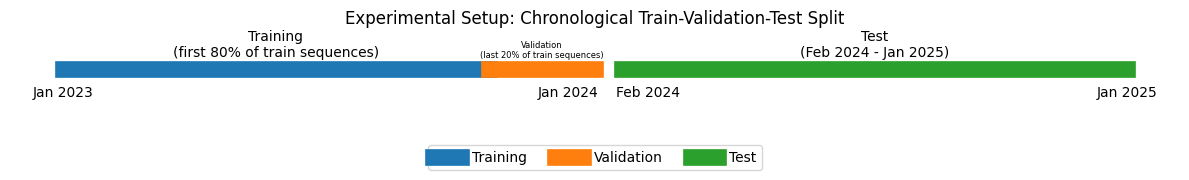

In [17]:
plt.figure(figsize=(12, 2))

# Training sequences region
plt.plot([0, 0.8], [1, 1], linewidth=12, label='Training')
plt.plot([0.8, 1.0], [1, 1], linewidth=12, label='Validation')
plt.plot([1.05, 2.0], [1, 1], linewidth=12, label='Test')

plt.text(0.4, 1.05, 'Training\n(first 80% of train sequences)', ha='center', va='bottom')
plt.text(0.9, 1.05, 'Validation\n(last 20% of train sequences)', ha='center', va='bottom', fontsize=6)
plt.text(1.525, 1.05, 'Test\n(Feb 2024 - Jan 2025)', ha='center', va='bottom')

plt.text(0, 0.85, 'Jan 2023', ha='center')
plt.text(0.95, 0.85, 'Jan 2024', ha='center')
plt.text(1.10, 0.85, 'Feb 2024', ha='center')
plt.text(2.0, 0.85, 'Jan 2025', ha='center')

plt.yticks([])
plt.xticks([])
plt.ylim(0.7, 1.2)
plt.xlim(-0.1, 2.1)
plt.title('Experimental Setup: Chronological Train-Validation-Test Split')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.box(False)
plt.tight_layout()
plt.show()

### Part 5
<span style="color:red">

- Choose a recurrent neural network architecture (5 pts)
- build the prediction model (e.g., LSTM, GRU, etc.) and implement your solution. 
- Motivate which hyperparameters you select or optimize.

</span>

In [18]:
# Build model
model = Sequential([
    LSTM(50, activation='tanh', input_shape=(window_size, 1)),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/Users/sadra/miniconda3/envs/1BM110_submit/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1405 - val_loss: 0.0826
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0348 - val_loss: 0.0735
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0371 - val_loss: 0.0723
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0311 - val_loss: 0.0694
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0340 - val_loss: 0.0677
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0304 - val_loss: 0.0698
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0331 - val_loss: 0.0677
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0299 - val_loss: 0.0664
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0325 - val_loss: 0.0661
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0314 - val_loss: 0.0658
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0288 - val_loss: 0.0656
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

### Hyperparameter Optimization

For our chosen RNN architecture (LSTM), we consider the following hyperparameters: 
- Number of LSTM units: 50
- window_size : 30
- Activation function: tanh
- Dropout rate: 0.2
- Optimizer: adam with learning rate (we're using the default 0.001)
- Loss function: mse
- Batch size: 32
- Number of epochs: 100
- Early stopping with patience = 10
- and ...


Since we're using Tensor already, we thought we could use Keras Tuner as opposed to the more commonly used tuner 'Optuna'.

In [19]:
# hyper parameter optimization using Keras Tuner
# for demonstration purposes, we will just do a simple random search over a few hyperparameters.

# defines which hyperparameters to tune: we chose to tune the number of LSTM units, dropout rate, learning rate and batch size.

def build_model(hp):
    model = Sequential([
        ## keeping the window size the same
        Input(shape=(window_size, 1)),
        LSTM(
            ## we already used 50 in out initial model
            units=hp.Choice("lstm_units", values=[32, 50, 64, 128]), 
            activation="tanh"
        ),
        Dropout(
            ## we already used 0.2 in our initial model
            rate=hp.Choice("dropout_rate", values=[0.1, 0.2, 0.3, 0.4])
        ),
        ## keeping this the same
        Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            ## we already used the default 1e-3 in our initial model
            learning_rate=hp.Choice("learning_rate", values=[1e-2, 1e-3, 1e-4])
        ),
        ## keepin this the same
        loss="mse"
    )

    return model

# a custom tuner to also tune batch size, using RandomSearch as the base tuner
class CustomTuner(kt.RandomSearch):
    def run_trial(self, trial, *args, **kwargs):
        hp = trial.hyperparameters
        ## we already used 32 in our initial model
        kwargs["batch_size"] = hp.Choice("batch_size", values=[16, 32, 64])
        return super().run_trial(trial, *args, **kwargs)


## keeping callback the same as initial model
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


## expaning our tuner with the CustomTuner class, which we defined above
tuner = CustomTuner(
    hypermodel=build_model,
    objective="val_loss",
    max_trials=3, # number of experiments (keeping it low for demonstration)
    overwrite=True,
    directory="part4",
    project_name="lstm_random_search"
)

# Run hyperparameter search
tuner.search(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    ## keeping epochs the same for all experiments
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

# Show best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
print("LSTM units     :", best_hp.get("lstm_units"))
print("Dropout rate   :", best_hp.get("dropout_rate"))
print("Learning rate  :", best_hp.get("learning_rate"))
print("Batch size     :", best_hp.get("batch_size"))


# # Build and train final model with best hyperparameters
# best_model = tuner.hypermodel.build(best_hp)

# history = best_model.fit(
#     X_tr, y_tr,
#     validation_data=(X_val, y_val),
#     epochs=100,
#     batch_size=best_hp.get("batch_size"),
#     callbacks=[early_stop],
#     verbose=1
# )

# # Show final model summary
# best_model.summary()

Trial 3 Complete [00h 00m 08s]
val_loss: 0.07344922423362732

Best val_loss So Far: 0.043122924864292145
Total elapsed time: 00h 00m 47s
Best hyperparameters found:
LSTM units     : 128
Dropout rate   : 0.3
Learning rate  : 0.001
Batch size     : 16


So based on the rather incomplete hyperparamtersearch we just did, we get the following results for best values

Best val_loss So Far: 0.043 slightly better than the initial model we used (see plot below)
- Best hyperparameters found:
    - LSTM units     : 128 (we used 50 initially)
    - Dropout rate   : 0.3 (we used .2)
    - Learning rate  : 0.001 (same, probably because of low number of experimients)
    - Batch size     : 16 (we used 32, again with more experiments this will likely change)

### Part 6: Create plots of training and validation losses. (2 pts)

<span style="color:red">

- Describe the trends you notice and whether they indicate underfitting or overfitting behaviors.

</span>

The training and validation loss curves both decrease during the first epochs, which indicates that the model is successfully learning patterns from the training data.

The training loss decreases throughout the training process while the validation loss reaches a stable point which shows matching patterns between both measurements.

The model demonstrates the ability to generalize to new data which it has not encountered before.

The training loss decreases while the validation loss remains stable which shows that the model does not show any signs of overfitting.

The model shows no signs of underfitting because it maintains moderate loss levels.

The loss curves show that the model achieves an effective balance between training data fitting and its ability to generalize to new data.

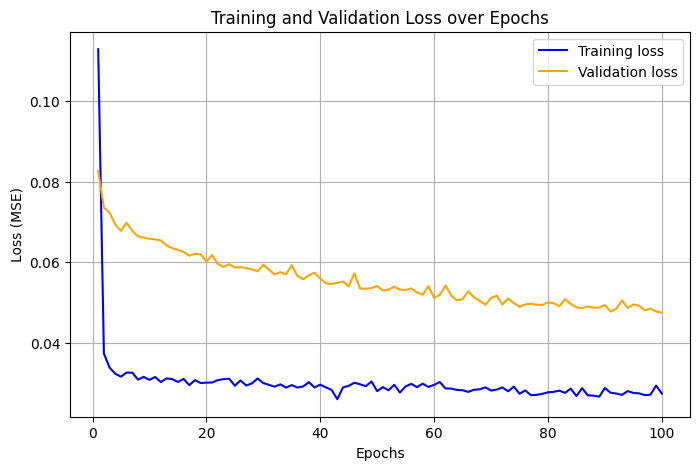

In [20]:
# history object contains the loss values per epoch
# we extract training loss and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# create the plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training loss', color='blue')
plt.plot(epochs, val_loss, label='Validation loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### Part 7: Evaluate the performance of the model. (3 pts)

<span style="color:red">

- Describe which measures you use and discuss the results of the evaluation.

</span>

We used four error metrics to assess model performance which included Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) and Mean Absolute Percentage Error (MAPE) and Median Absolute Error.

MAE calculates the average absolute difference between predicted values and actual values which shows the typical prediction error through its results.

The RMSE metric calculates the square root of average squared deviations which exist between predicted and actual outcomes. The RMSE method calculates an average by first squaring all errors which results in stronger penalties against larger prediction errors.

The MAPE metric calculates the average percentage difference between predicted values and actual values which allows for understanding prediction errors based on energy generation size.

We then calculated the Median Absolute Error which serves as a dependable measurement method because it shows less vulnerability to uncommon data points.

The evaluation results show that the model is able to capture the general behavior of non-renewable energy generation over time. The prediction errors remain within a reasonable range, indicating that the model can approximate the daily energy generation trends. The model shows accurate test period predictions which will experience some production variation during sudden production peaks and drops.

In [21]:
# --- Create test sequences using the last part of training as context ---
# Combine the scaled training and test targets into one array
combined_scaled = np.vstack([train_scaled, test_scaled])  # shape (762, 1)

# Create sequences from the combined series, but only keep those where the target index
# corresponds to a test day (i.e., index >= len(train_scaled))
window_size = 30
X_test_combined, y_test_combined = create_sequences(combined_scaled, window_size)

# The first test target is at position len(train_scaled) in the combined array.
# The corresponding sequence index in X_test_combined is: len(train_scaled) - window_size.
start_test_idx = len(train_scaled) - window_size  # index in X_test_combined where first test target appears
X_test = X_test_combined[start_test_idx:]        # all test inputs
y_test_scaled = y_test_combined[start_test_idx:] # true test targets (scaled)

print("X_test shape:", X_test.shape)
print("y_test_scaled shape:", y_test_scaled.shape)

# --- Generate predictions ---
y_pred_scaled = model.predict(X_test)

# --- Inverse transform to original scale ---
y_test_original = scaler.inverse_transform(y_test_scaled)
y_pred_original = scaler.inverse_transform(y_pred_scaled)

# --- Compute evaluation metrics ---

mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
# Mean Absolute Percentage Error (MAPE) - avoid division by zero
mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

print(f"Test set evaluation (original scale MW):")
print(f"MAE:  {mae:.2f} MW")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")


# y_test_original and y_pred_original already computed
mae = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
# Median Absolute Error (robust to outliers)
med_ae = np.median(np.abs(y_test_original - y_pred_original))

print(f"Test set evaluation (original scale MW):")
print(f"MAE:  {mae:,.0f} MW")
print(f"RMSE: {rmse:,.0f} MW")
print(f"Median AE: {med_ae:,.0f} MW")
print(f"Number of zero actuals: {(y_test_original == 0).sum()}")

X_test shape: (366, 30, 1)
y_test_scaled shape: (366, 1)
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Test set evaluation (original scale MW):
MAE:  177290.23 MW
RMSE: 232511.84 MW
MAPE: inf%
Test set evaluation (original scale MW):
MAE:  177,290 MW
RMSE: 232,512 MW
Median AE: 143,126 MW
Number of zero actuals: 8


/var/folders/86/60m68tfx6wdfjt93m00bhrx40000gn/T/ipykernel_37026/154198649.py:31: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100


### Part 8: Create a plot contrasting the predictions of the model and the ground truth values from the test set. (2 pts)

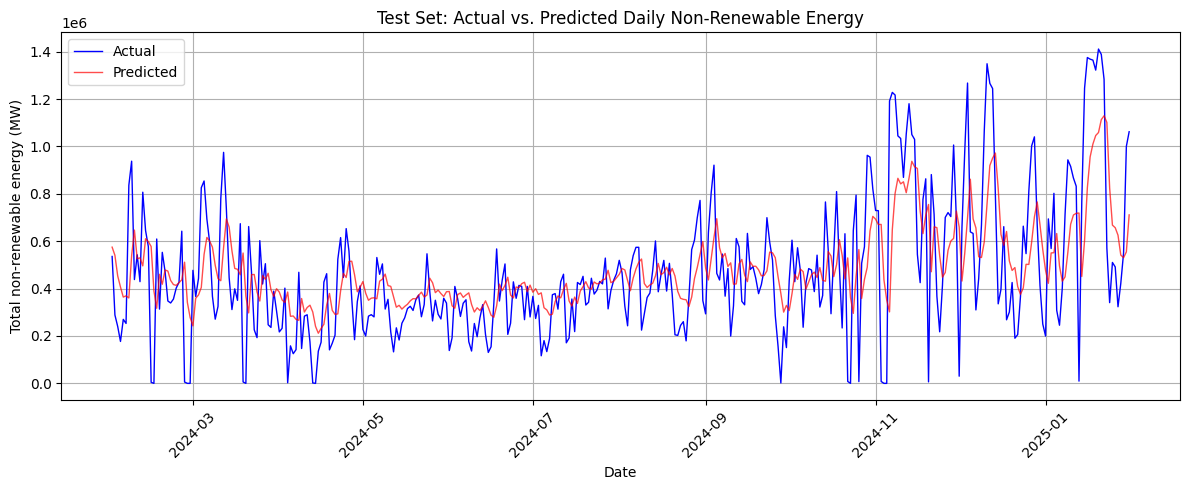

In [22]:
# Convert to 1D arrays for plotting
y_test_flat = y_test_original.flatten()
y_pred_flat = y_pred_original.flatten()

# Create a date range for the test period (Feb 2024 – Jan 2025)
test_dates = pd.date_range(start='2024-02-01', periods=len(y_test_flat), freq='D')

plt.figure(figsize=(12, 5))
plt.plot(test_dates, y_test_flat, label='Actual', color='blue', linewidth=1)
plt.plot(test_dates, y_pred_flat, label='Predicted', color='red', linewidth=1, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Total non-renewable energy (MW)')
plt.title('Test Set: Actual vs. Predicted Daily Non‑Renewable Energy')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()